Shape of dataset:
(1000, 8)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading scor

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


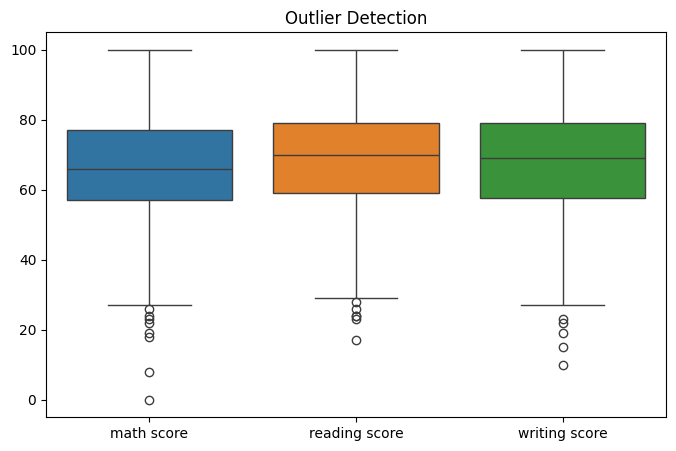


After Encoding and Scaling:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,-0.964625,-1.015044,-0.812640,0.741881,0.746748,0.390024,0.193999,0.391492
1,-0.964625,-0.150441,0.827953,0.741881,-1.339140,0.192076,1.427476,1.313269
2,-0.964625,-1.015044,0.281088,0.741881,0.746748,1.577711,1.770109,1.642475
3,1.036672,-1.879647,-1.359505,-1.347925,0.746748,-1.259543,-0.833899,-1.583744
4,1.036672,-0.150441,0.827953,0.741881,0.746748,0.653954,0.605158,0.457333


Training set shape: (800, 7)
Testing set shape: (200, 7)


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("StudentsPerformance.csv")

print("Shape of dataset:")
print(df.shape)

print("\nData Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

plt.figure(figsize=(8,5))
sns.boxplot(data=df[["math score","reading score","writing score"]])
plt.title("Outlier Detection")
plt.show()

# Preprocessing

label_encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = label_encoder.fit_transform(df[col])

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nAfter Encoding and Scaling:")
display(df.head())

X = df.drop("math score", axis=1)
y = df["math score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
